In [3]:
import tensorflow as tf
import os

c:\Users\anime\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [4]:
import cv2
import imghdr

In [5]:
data_dir='data'

image_exts=['png','jpg','jpeg','bmp']

In [6]:
len(os.listdir(os.path.join(data_dir,'happy')))

1211

In [7]:
len(os.listdir(os.path.join(data_dir,'sad')))

1419

In [8]:
for img_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,img_class)):
        image_path=os.path.join(data_dir,img_class,image)
        try:
            img = cv2.imread(image_path)
            if img is None:
                print(f"Corrupt image removed: {image_path}")
                os.remove(image_path)
                continue
            
            ext=imghdr.what(image_path)
            
            if ext not in image_exts:
                print(f'Image not accepted , {image_path}')
                os.remove(image_path)
                
                
        except Exception as e:
            print(f'Issue with image -:{image_path}')
            

In [9]:
import matplotlib.pyplot as plt 

In [10]:
image=cv2.imread(r'D:\PYTHON\DL\ImageClf-1\data\sad\360_F_215952710_x7ShPliGLljxkjMIL6jFbX4BuOo3N51B.jpg')

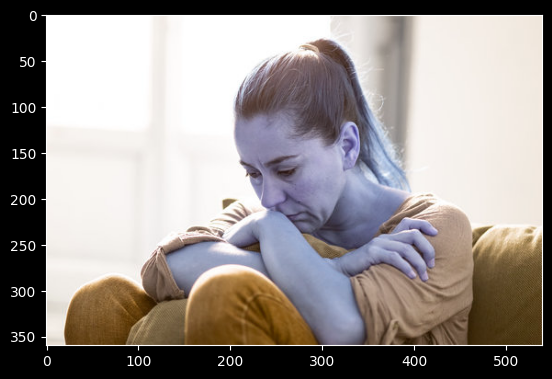

In [11]:
plt.imshow(image)

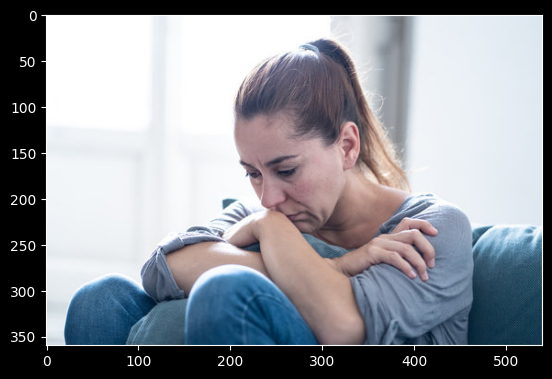

In [12]:
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

In [13]:
tf.data.Dataset??

Init signature: tf.data.Dataset(variant_tensor)
Source:        
@tf_export("data.Dataset", v1=[])
@six.add_metaclass(abc.ABCMeta)
class DatasetV2(collections_abc.Iterable, tracking_base.Trackable,
                composite_tensor.CompositeTensor):
  """Represents a potentially large set of elements.

  The `tf.data.Dataset` API supports writing descriptive and efficient input
  pipelines. `Dataset` usage follows a common pattern:

  1. Create a source dataset from your input data.
  2. Apply dataset transformations to preprocess the data.
  3. Iterate over the dataset and process the elements.

  Iteration happens in a streaming fashion, so the full dataset does not need to
  fit into memory.

  Source Datasets:

  The simplest way to create a dataset is to create it from a python `list`:

  >>> dataset = tf.data.Dataset.from_tensor_slices([1, 2, 3])
  >>> for element in dataset:
  ...   print(element)
  tf.Tensor(1, shape=(), dtype=int32)
  tf.Tensor(2, shape=(), dtype=int32)
  tf.Ten

In [14]:
import numpy as np

In [15]:
data=tf.keras.utils.image_dataset_from_directory('data')

Found 2630 files belonging to 2 classes.


In [16]:
tf.keras.utils.image_dataset_from_directory??

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    **kwargs,
)
Source:   
@keras_export('keras.utils.image_dataset_from_directory',
              'keras.preprocessing.image_dataset_from_directory',
              v1=[])
def image_dataset_from_directory(directory,
                                 labels='inferred',
                                 label_mode='int',
                                 class_names=None,
                                 color_mode='rgb',
                                 batch_size=32,
                                 image_size=(256, 256),
                                 shuffle=True,
                                 seed=None,
               

In [17]:
data_iterator=data.as_numpy_iterator()

In [18]:
data_iterator

In [19]:
batch=data_iterator.next()

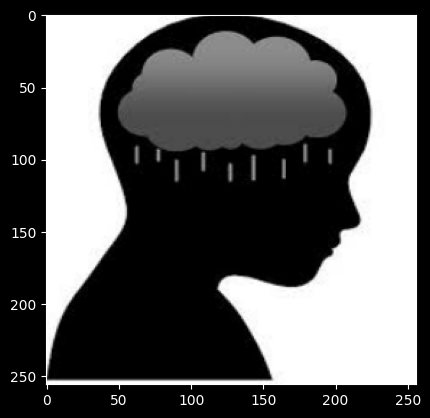

In [20]:
img_t1=batch[0][0]
plt.imshow(img_t1.astype('int'))

In [21]:
batch[1][0]

1

In [22]:
# 0->happy 
# 1-> sad

In [30]:
batch[0][0].max()-batch[0][0].min()

255.0

In [31]:
scaled = batch[0]/255

In [33]:
scaled.max()

1.0

In [34]:
data=data.map(lambda x,y:(x/255,y))

In [36]:
scaled_iterator=data.as_numpy_iterator()

In [38]:
scaled_iterator.next()

(array([[[[0.07809436, 0.09770221, 0.07417279],
          [0.07450981, 0.09411765, 0.07058824],
          [0.07282475, 0.0924326 , 0.06890319],
          ...,
          [0.07619485, 0.08403799, 0.07227328],
          [0.07450981, 0.08235294, 0.07058824],
          [0.07450981, 0.08235294, 0.07058824]],
 
         [[0.07809436, 0.09770221, 0.07417279],
          [0.07450981, 0.09411765, 0.07058824],
          [0.07282475, 0.0924326 , 0.06890319],
          ...,
          [0.08107719, 0.08892033, 0.07715562],
          [0.08020833, 0.08805147, 0.07628676],
          [0.08020833, 0.08805147, 0.07628676]],
 
         [[0.07759029, 0.09719813, 0.07366872],
          [0.07436763, 0.09397547, 0.07044606],
          [0.07251024, 0.09211808, 0.06858867],
          ...,
          [0.08627451, 0.09411765, 0.08235294],
          [0.08627451, 0.09411765, 0.08235294],
          [0.08627451, 0.09411765, 0.08235294]],
 
         ...,
 
         [[0.34595588, 0.3420343 , 0.32242647],
          [0.32945

In [43]:
train_size=int(len(data)*0.7)
val_size=int(len(data)*0.2)
test_size=int(len(data)*0.1)

In [45]:
train_size , val_size , test_size

(58, 16, 8)

In [46]:
train=data.take(train_size)
val =data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)

In [48]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Dropout,MaxPooling2D,Flatten